# MWPM decoder for X errors on a $d=5$ rotated surface code

This notebook walks end-to-end from raw syndromes through Minimum-Weight
Perfect Matching (MWPM) decoding, with the underlying graphs drawn at each
step.

## What MWPM is actually doing

A single $X$ error on a data qubit in the bulk anti-commutes with exactly
**two** Z-stabilizers (the two whose support contains that qubit). So in the
syndrome those two stabilizers light up. An X error on a *boundary* data qubit
anti-commutes with only **one** Z-stabilizer — the other "end" of the error
disappears into the X-boundary undetected.

A *chain* of $k$ adjacent X errors lights up only the two stabilizers at the
chain's *endpoints* — every interior stabilizer is flipped twice (once by the
error on each side) and so reports `0`. So:

> Every connected piece of the X-error pattern terminates either at **two
> defects** (lit Z-aux) or at **one defect plus the boundary**.

That is exactly the structure of a graph matching problem. Build a graph whose
nodes are the lit Z-aux plus a virtual *boundary node*, give each edge weight
equal to the length of the shortest X-chain that could explain that pair, and
the lowest-weight perfect matching is the most-likely error pattern under a
uniform-IID error model. Apply the matched X-chains as corrections.

## Conventions

- `"Up"` $= |0\rangle$, `"Dn"` $= |1\rangle$. All qubits initialised to `"Up"`.
- Measurement outcome `bit = 0` ⇔ aux ended in `Up` ⇔ no defect; `bit = 1` ⇔ defect.

## Layout

A *staggered* boundary placement is used here to avoid an anti-commutation
conflict the original `example.ipynb` layout has at the $(0,0)$ corner (left
and bottom aux there are different types but share a single data qubit).

| side   | aux positions                            | type |
|--------|-----------------------------------------:|:----:|
| left   | $(-0.5, y+0.5)$ for $y \in \{1,3\}$       | Z    |
| right  | $(d-0.5,\, y+0.5)$ for $y \in \{0,2\}$    | Z    |
| bottom | $(x+0.5,\, -0.5)$ for $x \in \{0,2\}$     | X    |
| top    | $(x+0.5,\, d-0.5)$ for $x \in \{1,3\}$    | X    |

Bulk aux at $(x+0.5, y+0.5)$ for $x,y \in \{0,\dots,d-2\}$: **Z** if $x+y$
even, **X** if $x+y$ odd. The X-type "open" boundaries are *top* and *bottom*
(an X chain reaching either disappears undetected); the Z-type boundaries are
*left* and *right*.

In [1]:
using ITensors, ITensorMPS, LinearAlgebra, Plots, Random
Random.seed!(0xC0DE)
const threshold = 1e-12
gr();   # GR backend for Plots

## 1 · Lattice

`data_coords` holds the 25 data qubit positions. `z_aux_list` and `x_aux_list`
hold the 12 + 12 ancilla positions, separated by stabilizer type so the
decoder can ignore the X-type when decoding X errors.

In [2]:
const d = 5

# 25 data qubits on integer grid
data_coords = vec([(x, y) for x in 0:(d-1), y in 0:(d-1)])

# Bulk aux: checkerboard split by parity of x+y
z_aux_list = Tuple{Float64,Float64}[]
x_aux_list = Tuple{Float64,Float64}[]
for x in 0:(d-2), y in 0:(d-2)
    push!((x + y) % 2 == 0 ? z_aux_list : x_aux_list, (x + 0.5, y + 0.5))
end

# Boundary aux (staggered to keep the stabilizer group consistent at corners)
for y in 1:2:(d-2);  push!(z_aux_list, (-0.5,    y + 0.5)); end   # left   (Z)
for y in 0:2:(d-2);  push!(z_aux_list, (d - 0.5, y + 0.5)); end   # right  (Z)
for x in 0:2:(d-2);  push!(x_aux_list, (x + 0.5, -0.5));    end   # bottom (X)
for x in 1:2:(d-2);  push!(x_aux_list, (x + 0.5, d - 0.5)); end   # top    (X)

all_coords    = vcat(data_coords, z_aux_list, x_aux_list)
sites         = siteinds("S=1/2", length(all_coords))
site_by_coord = Dict(coord => sites[i] for (i, coord) in enumerate(all_coords))

println("data:  ", length(data_coords),
        "   Z-aux: ", length(z_aux_list),
        "   X-aux: ", length(x_aux_list),
        "   total: ", length(all_coords))

data:  25   Z-aux: 12   X-aux: 12   total: 49


### Layout plot

Data qubits as small grey dots; **cyan** diamonds are Z-type ancillas (which
detect X errors), **magenta** diamonds are X-type ancillas (which detect Z
errors).

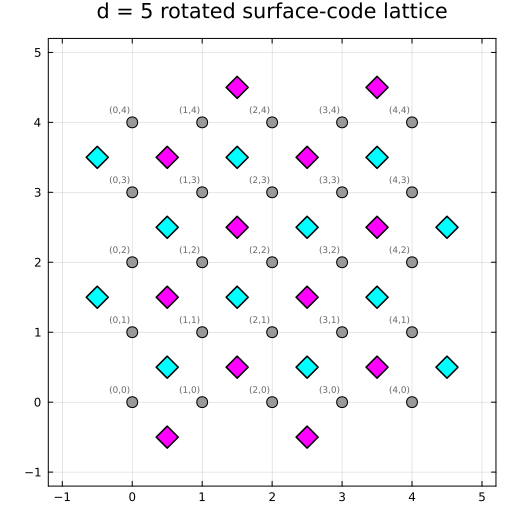

In [3]:
function plot_lattice(; title = "")
    p = plot(; aspect_ratio = :equal, legend = false, framestyle = :box,
              xlims = (-1.2, d + 0.2), ylims = (-1.2, d + 0.2),
              size = (520, 520), title = title)

    # Data qubits
    scatter!(p, [q[1] for q in data_coords], [q[2] for q in data_coords];
             color = :grey60, ms = 6, marker = :circle, label = "")
    for q in data_coords
        annotate!(p, q[1] - 0.18, q[2] + 0.18,
                  text("($(q[1]),$(q[2]))", 6, :grey40))
    end

    # Z-aux (cyan)
    scatter!(p, [a[1] for a in z_aux_list], [a[2] for a in z_aux_list];
             color = :cyan, ms = 11, marker = :diamond,
             markerstrokewidth = 1.5, markerstrokecolor = :black)

    # X-aux (magenta)
    scatter!(p, [a[1] for a in x_aux_list], [a[2] for a in x_aux_list];
             color = :magenta, ms = 11, marker = :diamond,
             markerstrokewidth = 1.5, markerstrokecolor = :black)

    p
end

plot_lattice(title = "d = $d rotated surface-code lattice")

## 2 · Stabilizer-measurement primitives

Each Z-stabilizer is measured with the standard syndrome-extraction circuit:
$\textsf{CNOT}_{d \to a}$ from every data qubit in its support to the auxiliary,
then a Z-basis measurement of the auxiliary. The CNOT chain copies the parity
of the data qubits' $|1\rangle$-population into the aux; measuring the aux
reads out that parity.

In [4]:
# Data qubits in the support of a given stabilizer (the 2 or 4 nearest data qubits)
data_neighbors_of(aux_coord) =
    [d for d in data_coords
       if abs(d[1] - aux_coord[1]) == 0.5 && abs(d[2] - aux_coord[2]) == 0.5]

# Projectors onto Up / Dn for an explicit post-measurement projection
P_up(s) = 0.5 * op("Id", s) + op("Sz", s)   # diag(1, 0) in (Up, Dn)
P_dn(s) = 0.5 * op("Id", s) - op("Sz", s)   # diag(0, 1)

# Projective Z-measurement on one aux qubit. Returns (bit, post-meas psi).
# bit = 0  <=>  aux ended in Up  =>  no defect
# bit = 1  <=>  aux ended in Dn  =>  defect
function measure_Z!(psi, aux_site; cutoff = threshold)
    sz = real(inner(psi', apply(op("Sz", aux_site), psi; cutoff)))
    if rand() < 0.5 + sz
        psi = apply(P_up(aux_site), psi; cutoff)
        bit = 0
    else
        psi = apply(P_dn(aux_site), psi; cutoff)
        bit = 1
    end
    return bit, psi / sqrt(real(inner(psi, psi)))
end

# One full Z-stabilizer measurement (CNOT chain + aux Z-measurement).
function measure_Z_stab(psi, aux_coord; cutoff = threshold)
    aux_site = site_by_coord[aux_coord]
    nbrs     = data_neighbors_of(aux_coord)
    # CNOT order from the paper's Fig. 2(a) (avoids hook errors).
    order    = length(nbrs) == 4 ? [2, 4, 1, 3] : [1, 2]
    for d_coord in nbrs[order]
        psi = apply(op("CNOT", site_by_coord[d_coord], aux_site), psi; cutoff)
    end
    return measure_Z!(psi, aux_site; cutoff)
end;

### Sanity check

With every data qubit in $|0\rangle$ and no errors, every Z-syndrome must be 0.

In [5]:
psi0 = MPS(sites, "Up")
SyndromeZ = Int[]
let psi = copy(psi0)
    for ac in z_aux_list
        bit, psi = measure_Z_stab(psi, ac)
        push!(SyndromeZ, bit)
    end
end
println("Z syndromes (expect all 0): ", SyndromeZ)
@assert all(==(0), SyndromeZ)

┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

Z syndromes (expect all 0): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 3 · The matching graph

We now build the graph that MWPM operates on. Walk every data qubit $q$:

- If $q$ is in the support of **two** Z-aux $a$ and $b$, add an edge
  $a \leftrightarrow b$ with weight 1, "labelled" by $q$. (A single X on $q$
  would flip both stabilizers.)
- If $q$ is in the support of **one** Z-aux $a$, add an edge from $a$ to the
  virtual boundary node $B$, also weight 1, labelled by $q$.
- If $q$ is in **zero** Z-aux (a data qubit only ever touched by X-aux), it
  contributes nothing to X-error decoding.

Multi-qubit error chains are handled implicitly: chain endpoints fire and the
shortest path in this graph between two endpoints has length equal to the
chain length. Computing all-pairs shortest paths via Floyd–Warshall gives the
edge weights of the *matching* graph (and the next-hop table lets us
reconstruct the actual data-qubit chain to correct).

In [6]:
const Nz   = length(z_aux_list)
const BND  = Nz + 1            # virtual boundary node id
const Ntot = Nz + 1

# Which Z-aux indices contain a given data qubit?
z_aux_containing(q) =
    [i for (i, a) in enumerate(z_aux_list)
       if abs(a[1] - q[1]) == 0.5 && abs(a[2] - q[2]) == 0.5]

# edge_data[(i,j)]  = data qubit q connecting Z-aux i and j  (i < j)
# bedge_data[i]     = data qubit q connecting Z-aux i to the boundary
# bnd_qubits_of[i]  = all data qubits connecting Z-aux i to the boundary (for plots)
edge_data     = Dict{Tuple{Int,Int}, Tuple{Int,Int}}()
bedge_data    = Dict{Int, Tuple{Int,Int}}()
bnd_qubits_of = Dict{Int, Vector{Tuple{Int,Int}}}()

for q in data_coords
    zs = z_aux_containing(q)
    if length(zs) == 2
        a, b = minmax(zs[1], zs[2])
        edge_data[(a, b)] = q
    elseif length(zs) == 1
        bedge_data[zs[1]] = q
        push!(get!(bnd_qubits_of, zs[1], Tuple{Int,Int}[]), q)
    end
end

println("internal edges (Z-aux <-> Z-aux): ", length(edge_data))
println("boundary edges (Z-aux <-> BND):   ", length(bedge_data),
        "  (",  sum(length, values(bnd_qubits_of)),
        " data qubits feed into them)")

internal edges (Z-aux <-> Z-aux): 15
boundary edges (Z-aux <-> BND):   6  (10 data qubits feed into them)


### Drawing the matching graph

- Solid lines: internal edges of the matching graph (weight 1).
- Dashed lines extending outwards: boundary edges. Each one terminates at a
  small "$\infty$" marker outside the lattice (all such markers represent the
  *same* virtual boundary node $B$).
- X-type ancillas are still drawn faintly, just for context — they aren't in
  this graph.

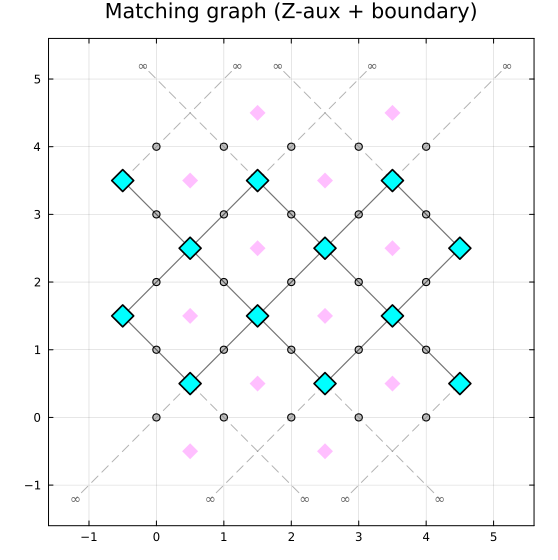

In [9]:
# Extend a boundary edge outward from its Z-aux through the boundary data qubit
function outward_point(zaux_idx, data_q; reach = 0.7)
    a = z_aux_list[zaux_idx]
    dx, dy = data_q[1] - a[1], data_q[2] - a[2]
    (a[1] + (1 + reach) * dx * 2, a[2] + (1 + reach) * dy * 2)
end

function draw_matching_graph!(p)
    # X-aux (faint, for context)
    scatter!(p, [a[1] for a in x_aux_list], [a[2] for a in x_aux_list];
             color = :magenta, ms = 8, marker = :diamond, alpha = 0.25,
             markerstrokewidth = 0)

    # Internal edges
    for ((i, j), _) in edge_data
        a, b = z_aux_list[i], z_aux_list[j]
        plot!(p, [a[1], b[1]], [a[2], b[2]];
              color = :black, lw = 1.2, alpha = 0.55, label = "")
    end

    # Boundary edges (one dashed line per boundary data qubit)
    for (i, qs) in bnd_qubits_of
        a = z_aux_list[i]
        for q in qs
            outside = outward_point(i, q)
            plot!(p, [a[1], outside[1]], [a[2], outside[2]];
                  color = :grey50, lw = 1.0, alpha = 0.6,
                  linestyle = :dash, label = "")
            annotate!(p, outside[1], outside[2], text("∞", 9, :grey40))
        end
    end

    # Z-aux nodes on top
    scatter!(p, [a[1] for a in z_aux_list], [a[2] for a in z_aux_list];
             color = :cyan, ms = 11, marker = :diamond,
             markerstrokewidth = 1.5, markerstrokecolor = :black, label = "")
    p
end

let p = plot(; aspect_ratio = :equal, legend = false, framestyle = :box,
              xlims = (-1.6, d + 0.6), ylims = (-1.6, d + 0.6),
              size = (560, 560),
              title = "Matching graph (Z-aux + boundary)")
    # Faint data qubits
    scatter!(p, [q[1] for q in data_coords], [q[2] for q in data_coords];
             color = :grey75, ms = 4, marker = :circle, label = "")
    draw_matching_graph!(p)
    display(p)
end

### All-pairs shortest paths

Floyd–Warshall fills out the full $\textsf{dist}$ matrix. We also keep
`nxt[i,j]` (the next hop on the shortest path from $i$ to $j$) so that once
MWPM gives us a pair $(a, b)$ to match, we can recover the actual chain of
data qubits to flip.

In [10]:
dist = fill(Inf, Ntot, Ntot)
nxt  = fill(-1,  Ntot, Ntot)
for i in 1:Ntot
    dist[i, i] = 0.0
    nxt[i, i]  = i
end
for ((a, b), _) in edge_data
    dist[a, b] = 1.0;  dist[b, a] = 1.0
    nxt[a, b]  = b;    nxt[b, a]  = a
end
for (a, _) in bedge_data
    dist[a, BND] = 1.0;  dist[BND, a] = 1.0
    nxt[a, BND]  = BND;  nxt[BND, a]  = a
end
for k in 1:Ntot, i in 1:Ntot, j in 1:Ntot
    if dist[i, k] + dist[k, j] < dist[i, j]
        dist[i, j] = dist[i, k] + dist[k, j]
        nxt[i, j]  = nxt[i, k]
    end
end

function path_between(a, b)
    nxt[a, b] == -1 && return Int[]
    p = [a]
    while a != b
        a = nxt[a, b]
        push!(p, a)
    end
    p
end;

## 4 · Brute-force MWPM

The matching problem: every defect (lit Z-aux) must be paired off, either
with another defect or with the boundary. We model this by adding *one
virtual boundary copy per defect*; boundary–boundary edges cost 0 so any
"spare" boundary copies pair off for free.

A brute recursive enumeration ($(2n-1)!!$ matchings for $n$ defects) is
plenty fast at $d=5$ with low error rates. Swap in PyMatching/BlossomV if
scaling up.

In [11]:
function mwpm(defects::Vector{Int})
    isempty(defects) && return Tuple{Int,Int}[], 0.0
    nd    = length(defects)
    nodes = vcat(defects, fill(BND, nd))   # one boundary copy per defect
    N     = length(nodes)

    # Augmented weight matrix
    W = zeros(N, N)
    for i in 1:N, j in (i+1):N
        if nodes[i] == BND && nodes[j] == BND
            W[i, j] = 0.0                 # spare-boundary pairing is free
        else
            W[i, j] = dist[nodes[i], nodes[j]]
        end
        W[j, i] = W[i, j]
    end

    function rec(rem::Vector{Int})
        isempty(rem) && return 0.0, Tuple{Int,Int}[]
        first  = rem[1]
        best_c = Inf
        best_m = Tuple{Int,Int}[]
        for k in 2:length(rem)
            c = W[first, rem[k]]
            isfinite(c) || continue
            sub_rem  = vcat(rem[2:k-1], rem[k+1:end])
            sc, sm   = rec(sub_rem)
            if c + sc < best_c
                best_c = c + sc
                best_m = vcat([(first, rem[k])], sm)
            end
        end
        return best_c, best_m
    end

    cost, m_idx = rec(collect(1:N))
    # Drop boundary-boundary "free" pairings — they're not real corrections.
    pairs = [(nodes[i], nodes[j]) for (i, j) in m_idx
             if !(nodes[i] == BND && nodes[j] == BND)]
    return pairs, cost
end;

## 5 · From matching to correction

Each matched pair $(a, b)$ corresponds to a *path* through the matching graph
(reconstructed via `nxt`); each step on that path is labelled by a single data
qubit. The full correction is the parity (XOR) of all those qubits — an even
number of X's on the same qubit cancels and shouldn't be applied.

In [12]:
# Data qubit lying on one edge of the matching graph
function qubit_on_edge(u, v)
    if u == BND
        return bedge_data[v]
    elseif v == BND
        return bedge_data[u]
    else
        return edge_data[minmax(u, v)]
    end
end

# Trace each matched path and collect the data qubits to X. Mod-2 the list.
function correction_qubits(pairs)
    qs = Tuple{Int,Int}[]
    for (a, b) in pairs
        p = path_between(a, b)
        for k in 1:(length(p) - 1)
            push!(qs, qubit_on_edge(p[k], p[k+1]))
        end
    end
    counts = Dict{Tuple{Int,Int}, Int}()
    for q in qs; counts[q] = get(counts, q, 0) + 1; end
    [q for (q, c) in counts if isodd(c)]
end

function apply_X!(psi, qubits; cutoff = threshold)
    for q in qubits
        psi = apply(op("X", site_by_coord[q]), psi; cutoff)
    end
    psi
end

function decode_and_correct(psi, syndrome::Vector{Int})
    defects     = [i for (i, b) in enumerate(syndrome) if b == 1]
    pairs, cost = mwpm(defects)
    correction  = correction_qubits(pairs)
    psi = apply_X!(psi, correction)
    return psi, defects, pairs, correction, cost
end;

## 6 · Verifying the correction

After applying the proposed correction, re-measure every Z-stabilizer; with a
successful decode the syndrome should be all 0. Each aux qubit needs to be
reset to `Up` before re-use, because the previous measurement already left it
in a definite computational-basis state.

In [13]:
function reset_aux!(psi, aux_coord; cutoff = threshold)
    aux_site = site_by_coord[aux_coord]
    sz = real(inner(psi', apply(op("Sz", aux_site), psi; cutoff)))
    if sz < 0   # aux is in Dn -> flip to Up
        psi = apply(op("X", aux_site), psi; cutoff)
    end
    psi
end

function measure_all_Z(psi)
    syn = Int[]
    for ac in z_aux_list
        psi = reset_aux!(psi, ac)
        bit, psi = measure_Z_stab(psi, ac)
        push!(syn, bit)
    end
    syn, psi
end;

### Visualisation helpers

`plot_decoder_state` draws the matching graph plus, on top:

- **Red** filled diamonds: defects (lit Z-aux).
- **Orange** thick line: the matched chain inside the matching graph.
- **Red ×**: the *true* X errors injected (ground truth — for our own
  inspection; the decoder doesn't see these).
- **Orange ○**: the data qubits the decoder proposes to X-correct.

In [14]:
function plot_decoder_state(syndrome, pairs, correction;
                            true_errors = Tuple{Int,Int}[],
                            title = "")
    p = plot(; aspect_ratio = :equal, legend = false, framestyle = :box,
              xlims = (-1.6, d + 0.6), ylims = (-1.6, d + 0.6),
              size = (560, 560), title = title)

    # Faint data qubits
    scatter!(p, [q[1] for q in data_coords], [q[2] for q in data_coords];
             color = :grey75, ms = 4, marker = :circle)
    draw_matching_graph!(p)

    # Matched paths drawn as orange chains through the graph
    for (a, b) in pairs
        path = path_between(a, b)
        for k in 1:(length(path) - 1)
            u, v = path[k], path[k+1]
            q    = qubit_on_edge(u, v)
            ucoord = u == BND ? outward_point(v, q) : z_aux_list[u]
            vcoord = v == BND ? outward_point(u, q) : z_aux_list[v]
            plot!(p, [ucoord[1], vcoord[1]], [ucoord[2], vcoord[2]];
                  color = :orange, lw = 4, alpha = 0.75)
        end
    end

    # Defects (lit Z-aux)
    lit = [z_aux_list[i] for (i, b) in enumerate(syndrome) if b == 1]
    if !isempty(lit)
        scatter!(p, [a[1] for a in lit], [a[2] for a in lit];
                 color = :red, ms = 13, marker = :diamond,
                 markerstrokewidth = 2, markerstrokecolor = :black)
    end

    # Decoder's proposed correction
    if !isempty(correction)
        scatter!(p, [q[1] for q in correction], [q[2] for q in correction];
                 color = :orange, ms = 11, marker = :circle,
                 markerstrokewidth = 2, markerstrokecolor = :black)
    end

    # Ground-truth injected errors (red x)
    if !isempty(true_errors)
        scatter!(p, [q[1] for q in true_errors], [q[2] for q in true_errors];
                 color = :red, ms = 12, marker = :xcross,
                 markerstrokewidth = 3)
    end

    p
end;

## 7 · Demo A — single bulk X error

X on data $(2,2)$. That qubit lies in two Z-stabilizers, at $(1.5,1.5)$ and
$(2.5,2.5)$, so we expect **two adjacent defects**. The matching graph has a
weight-1 edge directly between them, so MWPM matches them via that single
edge and proposes a single X on $(2,2)$ as the correction.

syndrome  : [0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0]
lit Z-aux : [(1.5, 1.5), (2.5, 2.5), (3.5, 1.5), (3.5, 3.5)]
defects   : [3, 6, 7, 8]
matching  : [(3, 6), (7, 8)]
correction: [(3, 2), (3, 3), (2, 2)]    (MWPM cost = 3.0)
post-corr syndrome (expect all 0): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


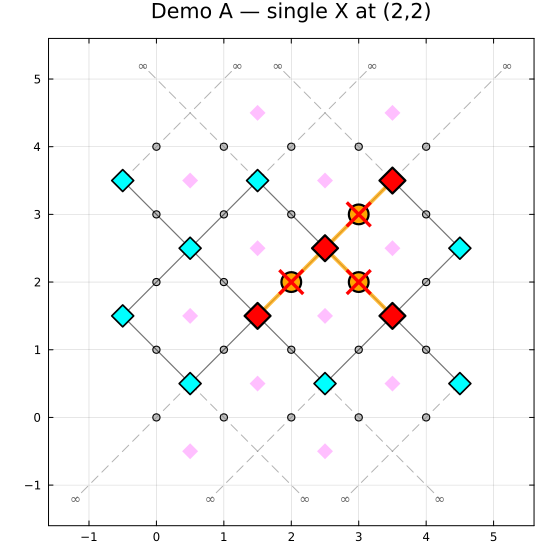

In [26]:
# err_qubits = [(2, 2)]
err_qubits = [(2, 2), (3, 2), (3,3)]

psi = let p = MPS(sites, "Up")
    for q in err_qubits
        p = apply(op("X", site_by_coord[q]), p; cutoff = threshold)
    end
    p
end

syn1, psi = measure_all_Z(psi)
println("syndrome  : ", syn1)
println("lit Z-aux : ", [z_aux_list[i] for (i, b) in enumerate(syn1) if b == 1])

psi, defects, pairs, correction, cost = decode_and_correct(psi, syn1)
println("defects   : ", defects)
println("matching  : ", pairs)
println("correction: ", correction, "    (MWPM cost = ", cost, ")")

syn2, psi = measure_all_Z(psi)
println("post-corr syndrome (expect all 0): ", syn2)
@assert all(==(0), syn2)

plot_decoder_state(syn1, pairs, correction;
                   true_errors = err_qubits,
                   title = "Demo A — single X at (2,2)")

## 8 · Demo B — adjacent two-error chain

X on $(1,1)$ and $(2,1)$. Both errors lie in the same bulk Z-stabilizer at
$(1.5, 1.5)$ — that stabilizer is flipped *twice* and so reports 0. Only the
two stabilizers at the *endpoints* of this chain light up: $(0.5, 0.5)$
(touched by the X on $(1,1)$) and $(2.5, 0.5)$ (touched by the X on $(2,1)$).
MWPM should pair those two endpoints with a weight-2 chain that reconstructs
the full two-qubit correction.

syndrome  : [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
lit Z-aux : [(0.5, 0.5), (2.5, 0.5)]
defects   : [1, 5]
matching  : [(1, 5)]
correction: [(1, 1), (2, 1)]    (MWPM cost = 2.0)
post-corr syndrome (expect all 0): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


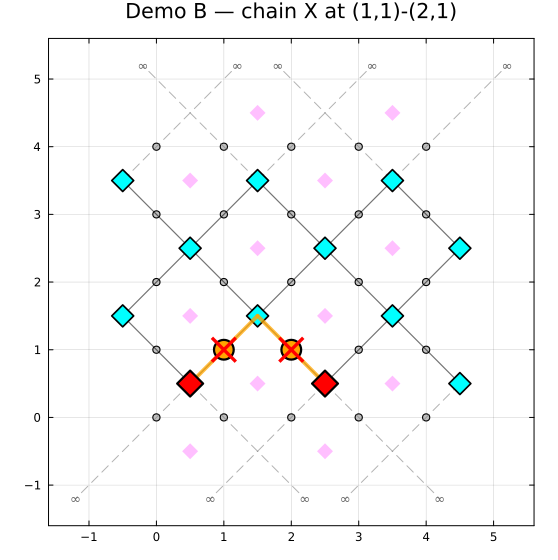

In [21]:
err_qubits = [(1, 1), (2, 1)]

psi = let p = MPS(sites, "Up")
    for q in err_qubits
        p = apply(op("X", site_by_coord[q]), p; cutoff = threshold)
    end
    p
end

syn1, psi = measure_all_Z(psi)
println("syndrome  : ", syn1)
println("lit Z-aux : ", [z_aux_list[i] for (i, b) in enumerate(syn1) if b == 1])

psi, defects, pairs, correction, cost = decode_and_correct(psi, syn1)
println("defects   : ", defects)
println("matching  : ", pairs)
println("correction: ", correction, "    (MWPM cost = ", cost, ")")

syn2, psi = measure_all_Z(psi)
println("post-corr syndrome (expect all 0): ", syn2)
@assert all(==(0), syn2)

plot_decoder_state(syn1, pairs, correction;
                   true_errors = err_qubits,
                   title = "Demo B — chain X at (1,1)-(2,1)")

## 9 · Demo C — boundary error

X on data $(0,0)$, a corner qubit lying in only **one** Z-aux, $(0.5,0.5)$.
That single defect cannot be paired with another defect — there is none — so
MWPM pairs it to the virtual boundary node. The correction is a single X on
$(0,0)$ and the orange matching path extends out through the dashed boundary
edge.

syndrome  : [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
lit Z-aux : [(0.5, 0.5)]
defects   : [1]
matching  : [(1, 13)]    (BND = 13)
correction: [(1, 0)]    (MWPM cost = 1.0)
post-corr syndrome (expect all 0): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


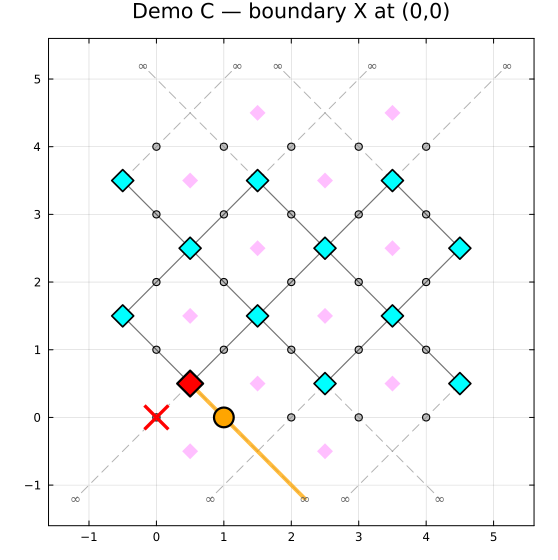

In [22]:
err_qubits = [(0, 0)]

psi = let p = MPS(sites, "Up")
    for q in err_qubits
        p = apply(op("X", site_by_coord[q]), p; cutoff = threshold)
    end
    p
end

syn1, psi = measure_all_Z(psi)
println("syndrome  : ", syn1)
println("lit Z-aux : ", [z_aux_list[i] for (i, b) in enumerate(syn1) if b == 1])

psi, defects, pairs, correction, cost = decode_and_correct(psi, syn1)
println("defects   : ", defects)
println("matching  : ", pairs, "    (BND = ", BND, ")")
println("correction: ", correction, "    (MWPM cost = ", cost, ")")

syn2, psi = measure_all_Z(psi)
println("post-corr syndrome (expect all 0): ", syn2)
@assert all(==(0), syn2)

plot_decoder_state(syn1, pairs, correction;
                   true_errors = err_qubits,
                   title = "Demo C — boundary X at (0,0)")

## 10 · Demo D — three scattered errors

A mix: a boundary error at $(4,4)$, a bulk error at $(1,2)$, and another
bulk error at $(3,2)$. Multiple defects light up; MWPM has to decide how to
pair them. The cheapest matching pairs the two bulk defects via a 2-step chain
and routes the corner defect to the boundary.

syndrome  : [0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0]
lit Z-aux : [(0.5, 2.5), (1.5, 1.5), (2.5, 2.5), (3.5, 1.5), (3.5, 3.5)]
defects   : [2, 3, 6, 7, 8]
matching  : [(2, 3), (6, 7), (8, 13)]    (BND = 13)
correction: [(3, 2), (1, 2), (4, 4)]    (MWPM cost = 3.0)
post-corr syndrome (expect all 0): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


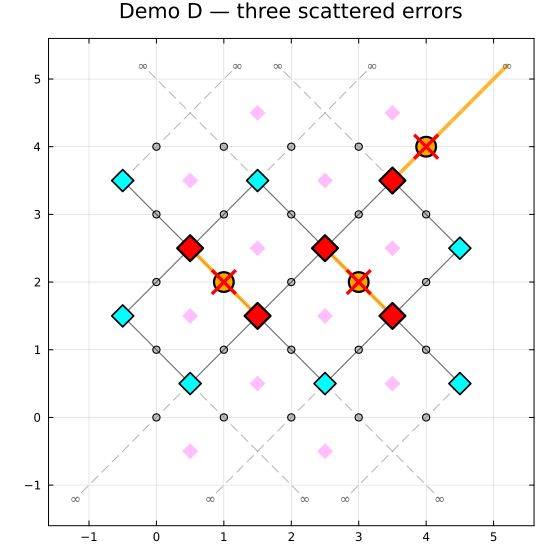

In [23]:
err_qubits = [(4, 4), (1, 2), (3, 2)]

psi = let p = MPS(sites, "Up")
    for q in err_qubits
        p = apply(op("X", site_by_coord[q]), p; cutoff = threshold)
    end
    p
end

syn1, psi = measure_all_Z(psi)
println("syndrome  : ", syn1)
println("lit Z-aux : ", [z_aux_list[i] for (i, b) in enumerate(syn1) if b == 1])

psi, defects, pairs, correction, cost = decode_and_correct(psi, syn1)
println("defects   : ", defects)
println("matching  : ", pairs, "    (BND = ", BND, ")")
println("correction: ", correction, "    (MWPM cost = ", cost, ")")

syn2, psi = measure_all_Z(psi)
println("post-corr syndrome (expect all 0): ", syn2)
@assert all(==(0), syn2)

plot_decoder_state(syn1, pairs, correction;
                   true_errors = err_qubits,
                   title = "Demo D — three scattered errors")